# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint



### Learning Objective

At the end of the experiment, you will be able to :

- Understand the concept of Gradient descent method
- Observe the effect of learning rate

In [ ]:
#@title Experiment Walkthrough Video
from IPython.display import HTML
HTML("""<video width='854' height='480' controls>
<source src="https://cdn.talentsprint.com/talentsprint1/archives/sc/aiml/aiml_2018_b7_hyd/preview_videos/gradient_descent.mp4" type='video/mp4'>
</video>""")

##Dataset

###Description


The dataset consists of two columns and 90 rows. Each column represents a characteristic of a simple pendulum i.e l (length) and t (time period). The dataset describes the relationship between the l and t which is  $l∝t^2$ .


##AI/ML Technique

#### Gradient Descent

Gradient Descent is used while training a machine learning model. It is an optimization algorithm, based on first order gradients, that tweaks it’s parameters iteratively to minimize a given function to its local minimum and global minima if the function is convex.

### Setup Steps:

In [18]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "2512297" #@param {type:"string"}


In [19]:
#@title Please enter your password (normally your phone number) to continue: { run: "auto", display-mode: "form" }
password = "7010198219" #@param {type:"string"}


##### After creating a copy of the notebook, follow the instructions below based on your batch:

* PG Batch: Run the below cell as it is.

* AC (Advanced) Batch: Follow the steps below to avoid execution errors.

1. Click on “Show Code” under the cell labeled:
    “Run this cell to complete the setup for this Notebook.”

2. Refer to the attached snippet and locate the red-highlighted section.

4. Add the following code snippet under the “Show Code” section, ensuring that the correct cohort ID is used in place of the example shown below:

           "batch": "IIITH-AC-AIML-27"  

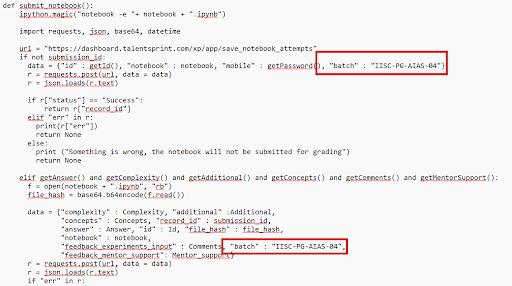

In [20]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython

ipython = get_ipython()

notebook= "U2W6_21_BatchGD_LRdecay_A" #name of the notebook

def setup():
#  ipython.magic("sx pip3 install torch")
    from IPython.display import HTML, display
    ipython.magic("sx wget -qq https://cdn.talentsprint.com/aiml/Experiment_related_data/week1/Exp1/AIML_DS_REGR01_SIMPLEPENDULUMOSCILLATIONDATA.txt")
    display(HTML('<script src="https://dashboard.talentsprint.com/aiml/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():

    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword(), "batch" : "IIITH-AC-AIML-27"}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print(r["err"])
        return None
      else:
        print ("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getComplexity() and getAdditional() and getConcepts() and getComments():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "id" : Id, "file_hash" : file_hash,
              "feedback_experiments_input" : Comments, "notebook" : notebook, "batch" : "IIITH-AC-AIML-27"}

      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iiith.talentsprint.com/notebook_submissions")
        # print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
      return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None
def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None

def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()

else:
  print ("Please complete Id and Password cells before running setup")

Setup completed successfully


## Import the required Packages


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

## Load the data

In [38]:
# Load the data by using pandas read_csv()
data = pd.read_csv("AIML_DS_REGR01_SIMPLEPENDULUMOSCILLATIONDATA.txt", sep=" ", header=None, names=['l', 't'])

# YOUR CODE HERE: Display the first 5 rows of dataframe 'data'
data.head()

# YOUR CODE HERE: Display the last 5 rows of dataframe 'data'
#data.tail()

,l,t
0,0.10,0.69004
1,0.11,0.69497
2,0.12,0.74252
3,0.13,0.75360
4,0.14,0.83568


In [39]:
# Get the length and time period values from the dataset
l = data['l'].values
t = data['t'].values
# Get the square of the time variable to form a linear equation
tsq = t * t

In [40]:
#data.head()
print(tsq)

[0.4761552  0.4829833  0.55133595 0.56791296 0.69836106 0.75323305
 0.70866091 0.72895736 0.73551206 0.78127921 0.80973002 0.96896461
 1.04939536 1.11767184 0.98162519 1.01163364 1.15068529 1.19749249
 1.30690624 1.21992025 1.40825689 1.29618225 1.49940025 1.53908836
 1.45709041 1.60224964 1.68870025 1.72712164 1.60351569 1.58206084
 1.68766081 1.70511364 1.81656484 1.82412036 1.97233936 1.94546704
 1.9044     2.096704   2.00732224 2.16648961 2.14798336 2.07331201
 2.30250276 2.24640144 2.17592001 2.34886276 2.33998209 2.36298384
 2.59016836 2.67387904 2.51000649 2.76989449 2.55584169 2.75062225
 2.66244489 2.91521476 2.77355716 2.73935601 2.87777296 2.93882449
 3.13502436 3.10534884 2.979076   3.27211921 3.20589025 3.03735184
 3.37861161 3.30585124 3.19158225 3.23820025 3.34743616 3.46890625
 3.46816129 3.37934689 3.45699649 3.58875136 3.84081604 3.61
 3.70331536 3.76243609 3.779136   3.88799524 3.75700689 3.82398025
 4.00240036 3.93665281 4.02644356 4.19963049 4.20373009 4.08605796]


## Gradient Descent

Gradient descent is an optimization algorithm used to find the values of parameters (coefficients) of a function that minimizes a cost function.

A cost function is a measure of how wrong the model is in terms of its ability to estimate the relationship between X and y. This is typically expressed as a difference or distance between the predicted value and the actual value.

### Batch Gradient Descent

Batch gradient descent is a variation of the gradient descent algorithm that calculates the error for each example in the training dataset, but only updates the model after all training examples have been evaluated.

Firstly, we calculate the cost function which is $E$ = $(y - y_i)^2$ and we tweak the slope m and bias c to reduce the cost function.

$\frac{\partial E_i }{\partial m}$ = $ \frac{-2}{n} \sum_{i=1}^{n} (y_i - (mx_i + c)) * x_i$

$\frac{\partial E_i }{\partial c}$ = $ \frac{-2}{n} \sum_{i=1}^{n}(y_i - (mx_i + c))$

And then we update the slope and bias with with change in slope $\Delta m$ and change in bias $\Delta c$ with learning rate $eta$

$m$  = $m - \Delta m * eta$

$c$  = $c - \Delta c * eta$



In [41]:
"""
The function 'train' updates the values of m and c and calculates error.
The loss is minimized due to the changed values of m and c.
The new values m, c and the minimized error is returned.
"""
def train(x, y, m, c, eta):
    const = - 2.0/len(y)
    ycalc = m*x+c
    # YOUR CODE HERE: To define the line equation i.e y = mx + c
    # YOUR CODE HERE: To calculate the gradients ("delta_m" and "delta_c")
    delta_m = const * sum(x * (y - ycalc))
    delta_c = const* sum(y - ycalc)
    m = m - delta_m * eta
    c = c - delta_c * eta
    error = sum((y - ycalc)**2)/len(y)
    return m, c, error,y,ycalc

### Effect of varying LR (learning rate, $\eta$) on error and final line

Let us vary LR and find how the error decreases in each case, and how the final line looks, by training each case for the same number of iterations - 2000.

# #### $\eta$ (Learning rate) = 0.1

In [42]:
# Save errors
errs_1 = []
# Initialize m,c value
m, c = 0, 0
eta = 0.1 # Learning rate

# Call the train() method for 2000 iterations to update m and c and get error value with eta = 0.1.
for iteration in range(2000):
    m, c, error,y,ycalc = train(l, tsq, m, c, eta)
    errs_1.append(error)
    print("m = {0:.6} c = {1:.6} Error = {2:.6}".format(m, c, errs_1[-1]))
    # YOUR CODE HERE: Call 'train' function defined above by passing 'l', 'tsq', 'm', 'c', 'eta' as it's arguments.
    # YOUR CODE HERE: To append the errors to "errs_1"

# Save final line
m_1, c_1 = m, c

m = 0.309948 c = 0.466138 Error = 6.59679
m = 0.546491 c = 0.805264 Error = 3.87305
m = 0.728825 c = 1.05078 Error = 2.3863
m = 0.871104 c = 1.22732 Error = 1.57225
m = 0.983768 c = 1.35304 Error = 1.12408
m = 1.07451 c = 1.44134 Error = 0.874954
m = 1.14902 c = 1.50209 Error = 0.734171
m = 1.21147 c = 1.54257 Error = 0.652404
m = 1.26496 c = 1.56814 Error = 0.602832
m = 1.31176 c = 1.58277 Error = 0.57087
m = 1.35356 c = 1.58937 Error = 0.548585
m = 1.39159 c = 1.5901 Error = 0.531662
m = 1.42676 c = 1.58653 Error = 0.517754
m = 1.45976 c = 1.57985 Error = 0.50558
m = 1.49109 c = 1.5709 Error = 0.494444
m = 1.5211 c = 1.56033 Error = 0.483964
m = 1.55008 c = 1.5486 Error = 0.473932
m = 1.57822 c = 1.53606 Error = 0.464232
m = 1.60568 c = 1.52296 Error = 0.454799
m = 1.63257 c = 1.50949 Error = 0.445597
m = 1.65896 c = 1.49578 Error = 0.436603
m = 1.68493 c = 1.48193 Error = 0.427804
m = 1.71051 c = 1.46803 Error = 0.419192
m = 1.73574 c = 1.45411 Error = 0.410758
m = 1.76065 c = 1.440

In [13]:
print("m = {0:.6} c = {1:.6} Error = {2:.6}".format(m_1, c_1, errs_1[-1]))

m = 4.14148 c = 0.0735804 Error = 0.00706773


#### $\eta$ = 0.01

In [43]:
# Save errors
errs_01 = []
m, c = 0, 0
eta = 0.01  # Learning rate

# Call the train() method for 2000 iterations to update m and c and get error value with eta = 0.01.
for iteration in range(2000):
    m, c, error,y,ycalc = train(l,tsq,m,c,eta)# YOUR CODE HERE : Call 'train' function defined above by passing 'l', 'tsq', 'm', 'c', 'eta' as it's arguments.
    # YOUR CODE HERE: To append the errors to "errs_01"
    errs_01.append(error)
    print("m = {0:.6} c = {1:.6} Error = {2:.6}".format(m, c, errs_1[-1]))
# Save final line
m_01, c_01 = m, c

m = 0.0309948 c = 0.0466138 Error = 0.00706773
m = 0.0612556 c = 0.0919575 Error = 0.00706773
m = 0.0908015 c = 0.136064 Error = 0.00706773
m = 0.119651 c = 0.178967 Error = 0.00706773
m = 0.147823 c = 0.220697 Error = 0.00706773
m = 0.175335 c = 0.261286 Error = 0.00706773
m = 0.202203 c = 0.300763 Error = 0.00706773
m = 0.228446 c = 0.339157 Error = 0.00706773
m = 0.254078 c = 0.376498 Error = 0.00706773
m = 0.279117 c = 0.412812 Error = 0.00706773
m = 0.303577 c = 0.448128 Error = 0.00706773
m = 0.327474 c = 0.48247 Error = 0.00706773
m = 0.350823 c = 0.515865 Error = 0.00706773
m = 0.373637 c = 0.548337 Error = 0.00706773
m = 0.395931 c = 0.579912 Error = 0.00706773
m = 0.417718 c = 0.610612 Error = 0.00706773
m = 0.439012 c = 0.64046 Error = 0.00706773
m = 0.459825 c = 0.669479 Error = 0.00706773
m = 0.480171 c = 0.697691 Error = 0.00706773
m = 0.50006 c = 0.725118 Error = 0.00706773
m = 0.519506 c = 0.751778 Error = 0.00706773
m = 0.538519 c = 0.777694 Error = 0.00706773
m = 0.55

#### $\eta$ = 0.001

In [44]:
# Save errors
errs_001 = []
m, c = 0, 0
eta = 0.001 # Learning rate

# Call the train() method for 2000 iterations to update m and c and get error value with eta = 0.001.
for iteration in range(2000):
    m, c, error,y,ycalc = train(l,tsq,m,c,eta) # YOUR CODE HERE: Call 'train' function defined above by passing 'l', 'tsq', 'm', 'c', 'eta' as it's arguments.
    # YOUR CODE HERE: To append the errors to "errs_001"
    errs_001.append(error)
    print("m = {0:.6} c = {1:.6} Error = {2:.6}".format(m, c, errs_1[-1]))

# Save final line
m_001, c_001 = m, c

m = 0.00309948 c = 0.00466138 Error = 0.00706773
m = 0.00619163 c = 0.00931006 Error = 0.00706773
m = 0.00927645 c = 0.0139461 Error = 0.00706773
m = 0.012354 c = 0.0185694 Error = 0.00706773
m = 0.0154242 c = 0.0231802 Error = 0.00706773
m = 0.0184872 c = 0.0277784 Error = 0.00706773
m = 0.0215429 c = 0.0323641 Error = 0.00706773
m = 0.0245914 c = 0.0369373 Error = 0.00706773
m = 0.0276327 c = 0.041498 Error = 0.00706773
m = 0.0306668 c = 0.0460462 Error = 0.00706773
m = 0.0336937 c = 0.0505821 Error = 0.00706773
m = 0.0367135 c = 0.0551056 Error = 0.00706773
m = 0.0397262 c = 0.0596167 Error = 0.00706773
m = 0.0427317 c = 0.0641156 Error = 0.00706773
m = 0.0457302 c = 0.0686021 Error = 0.00706773
m = 0.0487215 c = 0.0730765 Error = 0.00706773
m = 0.0517058 c = 0.0775386 Error = 0.00706773
m = 0.0546831 c = 0.0819885 Error = 0.00706773
m = 0.0576534 c = 0.0864263 Error = 0.00706773
m = 0.0606166 c = 0.090852 Error = 0.00706773
m = 0.0635729 c = 0.0952656 Error = 0.00706773
m = 0.06652

#### $\eta$ = 0.0001

In [45]:
# Save errors
errs_0001 = []
m, c = 0, 0
eta = 0.0001 # Learning rate

# Call the train() method for 2000 iterations to update m and c and get error value with eta = 0.0001.
for iteration in range(2000):
    m, c, error,y,ycalc = train(l,tsq,m,c,eta) # YOUR CODE HERE: Call 'train' function defined above by passing 'l', 'tsq', 'm', 'c', 'eta' as it's arguments.
    # YOUR CODE HERE: To append the errors to "errs_0001"
    errs_0001.append(error)
    print("m = {0:.6} c = {1:.6} Error = {2:.6}".format(m, c, errs_1[-1]))
# Save final line
m_0001, c_0001 = m, c

m = 0.000309948 c = 0.000466138 Error = 0.00706773
m = 0.000619823 c = 0.000932149 Error = 0.00706773
m = 0.000929625 c = 0.00139803 Error = 0.00706773
m = 0.00123935 c = 0.00186379 Error = 0.00706773
m = 0.00154901 c = 0.00232942 Error = 0.00706773
m = 0.00185859 c = 0.00279492 Error = 0.00706773
m = 0.0021681 c = 0.0032603 Error = 0.00706773
m = 0.00247753 c = 0.00372555 Error = 0.00706773
m = 0.00278689 c = 0.00419067 Error = 0.00706773
m = 0.00309618 c = 0.00465567 Error = 0.00706773
m = 0.0034054 c = 0.00512054 Error = 0.00706773
m = 0.00371454 c = 0.00558528 Error = 0.00706773
m = 0.00402361 c = 0.0060499 Error = 0.00706773
m = 0.0043326 c = 0.00651438 Error = 0.00706773
m = 0.00464153 c = 0.00697875 Error = 0.00706773
m = 0.00495037 c = 0.00744298 Error = 0.00706773
m = 0.00525915 c = 0.00790709 Error = 0.00706773
m = 0.00556785 c = 0.00837108 Error = 0.00706773
m = 0.00587648 c = 0.00883493 Error = 0.00706773
m = 0.00618504 c = 0.00929866 Error = 0.00706773
m = 0.00649352 c = 0

### Plot of lines vs $\eta$ (Learning rate)

In [46]:
# Find the lines
y_1 = m_1 * l + c_1
y_01 = m_01 * l + c_01
y_001 = m_001 * l + c_001
y_0001 = m_0001 * l + c_0001

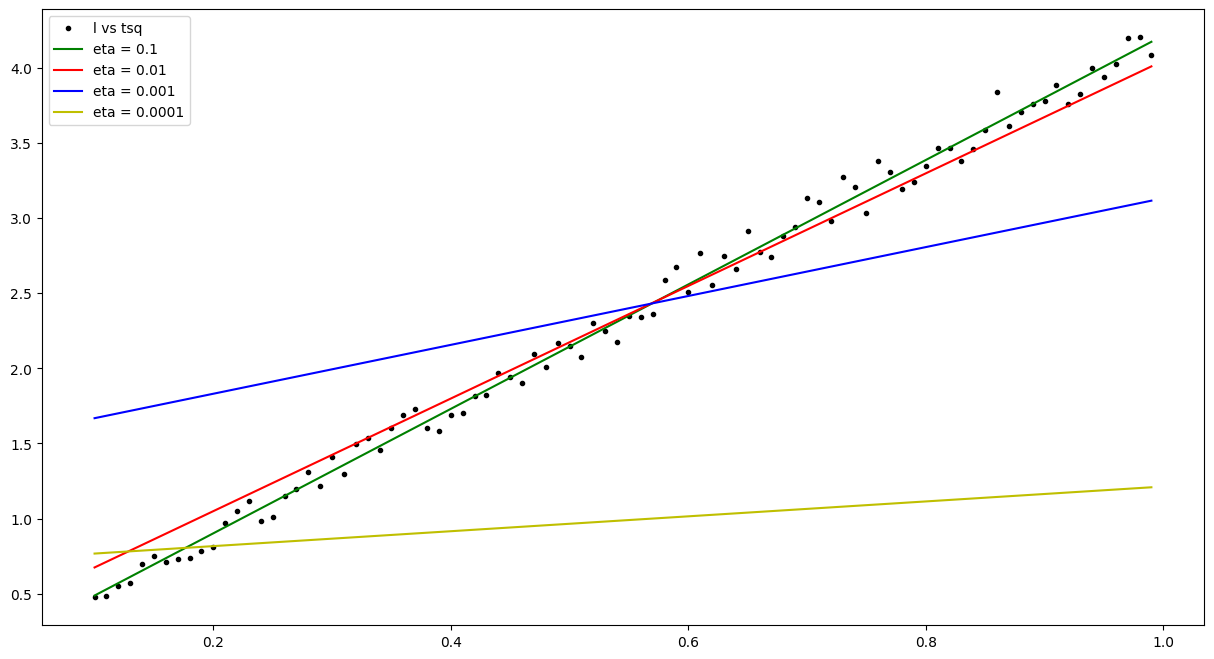

In [48]:
plt.figure(figsize=(15, 8))

# YOUR CODE HERE: For all the lines above i.e. y_1, y_01, y_001, y_0001 plot them (in a different color) against the lines "l"

plt.plot(l, tsq, '.k')
plt.plot(l, y_1, "g")
plt.plot(l, y_01, "r")
plt.plot(l, y_001, "b")
plt.plot(l, y_0001, "y")
plt.legend(["l vs tsq","eta = 0.1","eta = 0.01","eta = 0.001","eta = 0.0001"])
plt.show()


Thus, we see that higher learning rates reach the best fit faster than lower learning rates (obviously).

### Plot of errors vs epochs for each $\eta$ (Learning rate)

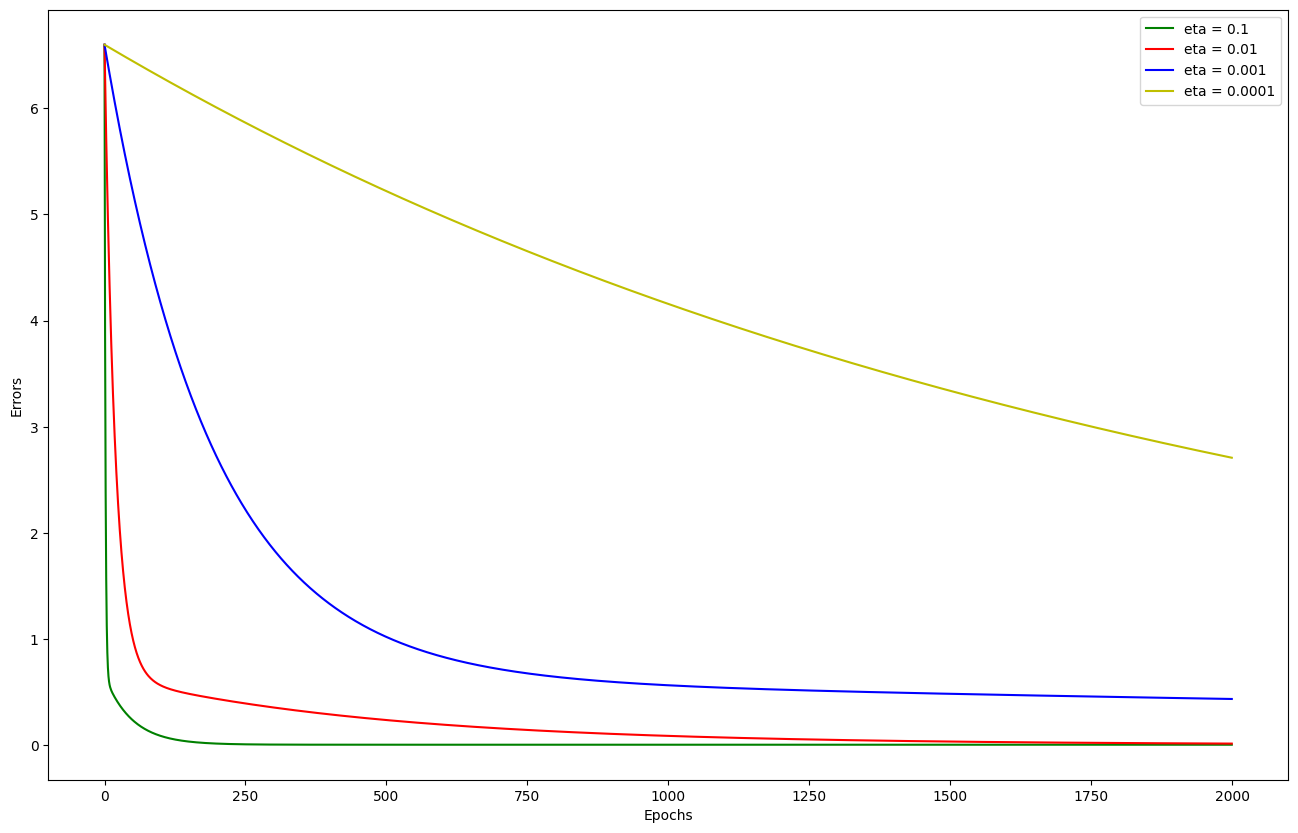

In [49]:
epochs = range(0,2000)
plt.figure(figsize=(16,10))
# YOUR CODE HERE: To plot "epochs" versus errs_1, errs_01, errs_001, errs_0001 (each in a different color)
plt.plot(epochs, errs_1, "g")
plt.plot(epochs, errs_01,"r")
plt.plot(epochs, errs_001,"b")
plt.plot(epochs, errs_0001,"y")
plt.legend(["eta = 0.1","eta = 0.01","eta = 0.001","eta = 0.0001"])
plt.xlabel('Epochs')
plt.ylabel('Errors')
plt.show()

### With LR (learning rate, $\eta$) Decay

In some cases, the learning rate might be too high to give good fitting lines. For example, let us train with constant LR (learning rate, $\eta$) of 0.8 and get the final line after 1000 iterations:

#### $\eta$ = 0.8

In [51]:
errs = []
m, c = 0, 0
eta = 0.8

# YOUR CODE HERE: Call the train() method for 1000 iterations to update m and c and get error value with constant eta = 0.8.
for iteration in range(1000):
    m, c, error,y,ycalc = train(l, tsq, m, c, eta)
    errs.append(error)
    print("m = {0:.6} c = {1:.6} Error = {2:.6}".format(m, c, errs_1[-1]))
m_normal, c_normal = m, c

m = 2.47959 c = 3.7291 Error = 0.00706773
m = 0.261234 c = -0.670558 Error = 0.00706773
m = 3.17319 c = 3.90364 Error = 0.00706773
m = 0.398111 c = -1.3801 Error = 0.00706773
m = 3.84896 c = 4.21001 Error = 0.00706773
m = 0.412599 c = -2.15319 Error = 0.00706773
m = 4.52913 c = 4.66123 Error = 0.00706773
m = 0.302612 c = -3.01704 Error = 0.00706773
m = 5.23657 c = 5.27545 Error = 0.00706773
m = 0.0618551 c = -4.00245 Error = 0.00706773
m = 5.9955 c = 6.07664 Error = 0.00706773
m = -0.320475 c = -5.14496 Error = 0.00706773
m = 6.83243 c = 7.09553 Error = 0.00706773
m = -0.860145 c = -6.48609 Error = 0.00706773
m = 7.77697 c = 8.3708 Error = 0.00706773
m = -1.57852 c = -8.0749 Error = 0.00706773
m = 8.86301 c = 9.95051 Error = 0.00706773
m = -2.50339 c = -9.96975 Error = 0.00706773
m = 10.1299 c = 11.8939 Error = 0.00706773
m = -3.67005 c = -12.2405 Error = 0.00706773
m = 11.6237 c = 14.2737 Error = 0.00706773
m = -5.12261 c = -14.971 Error = 0.00706773
m = 13.3993 c = 17.1786 Error = 0.

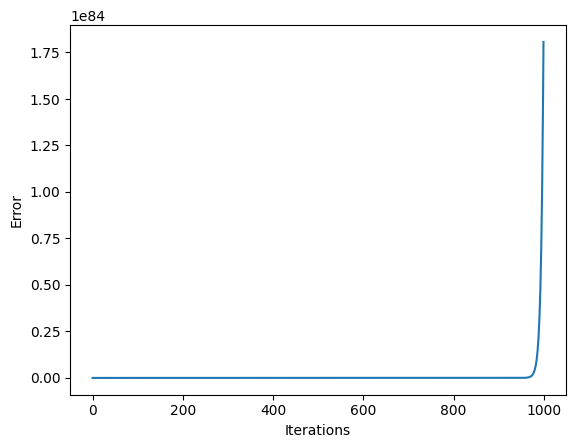

In [52]:
# YOUR CODE HERE: Plot errors vs iterations
plt.plot(range(len(errs)), errs)
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.show()

We see that the error quickly goes to almost 0, but after some iterations it blows up.

Let us check the "best fit" line that is found:

In [53]:
print("m = {0:.6} c = {1:.6} Error = {2:.6}".format(m_normal, c_normal, errs[-1]))

m = -6.43359e+41 c = -1.1198e+42 Error = 1.80675e+84


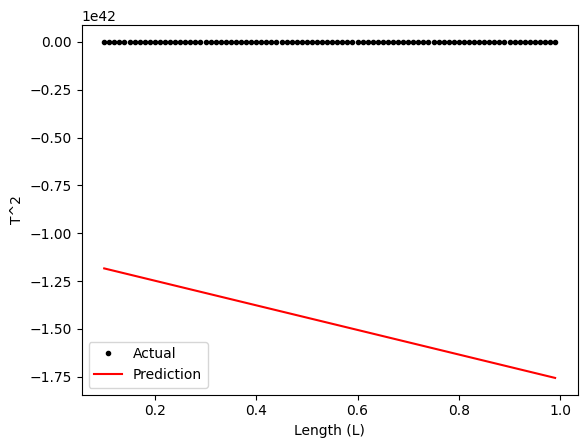

In [54]:
y = m_normal * l + c_normal
plt.plot(l, tsq, '.k', label = 'Actual')
plt.plot(l, y, "r", label = 'Prediction')
plt.xlabel("Length (L)")
plt.ylabel("T^2")
plt.legend()
plt.show()

Clearly this is not ideal.

This was a simple case where we can see the learning rate is too high. There might be cases where it is not so simple to identify this. Also, having a low learning rate is not good because training time would be too high!

**Solution: Decay the learning rate.**

Now let us train another model with decaying lr. But let us not decay lr below 0.0001.

In [55]:
errs_decay = []
m, c = 0, 0
eta = 0.5
decay_factor = 0.99

# Call the train() method for 1000 iterations to update m and c and get error value with decaying eta.
for iteration in range(1000):
    eta = max(0.0001, eta * decay_factor)
    m, c, error,y,ycalc = train(l, tsq, m, c, eta)
    errs_decay.append(error)
    print("m = {0:.6} c = {1:.6} Error = {2:.6}".format(m, c, errs_decay[-1]))
m_decay, c_decay = m, c

m = 1.53424 c = 2.30738 Error = 6.59679
m = 1.27252 c = 1.5107 Error = 1.12659
m = 1.52727 c = 1.63341 Error = 0.578583
m = 1.62604 c = 1.50365 Error = 0.48656
m = 1.75683 c = 1.4474 Error = 0.437618
m = 1.8703 c = 1.37756 Error = 0.396366
m = 1.97955 c = 1.31587 Error = 0.359589
m = 2.08199 c = 1.25678 Error = 0.326622
m = 2.17871 c = 1.20126 Error = 0.297029
m = 2.26994 c = 1.14884 Error = 0.270439
m = 2.35607 c = 1.09936 Error = 0.246524
m = 2.43741 c = 1.05262 Error = 0.224992
m = 2.51427 c = 1.00847 Error = 0.205588
m = 2.58692 c = 0.966722 Error = 0.188084
m = 2.65564 c = 0.92724 Error = 0.172279
m = 2.72067 c = 0.889881 Error = 0.157996
m = 2.78223 c = 0.854515 Error = 0.145075
m = 2.84053 c = 0.821018 Error = 0.133375
m = 2.89577 c = 0.78928 Error = 0.122772
m = 2.94814 c = 0.759193 Error = 0.113155
m = 2.9978 c = 0.730659 Error = 0.104423
m = 3.04493 c = 0.703585 Error = 0.0964877
m = 3.08966 c = 0.677887 Error = 0.0892709
m = 3.13213 c = 0.653484 Error = 0.0827015
m = 3.17248

In [56]:
print("m = {0:.6} c = {1:.6} Error = {2:.6}".format(m_decay, c_decay, errs_decay[-1]))

m = 4.12371 c = 0.0837925 Error = 0.00708933


Let us see the plot of error vs iterations:

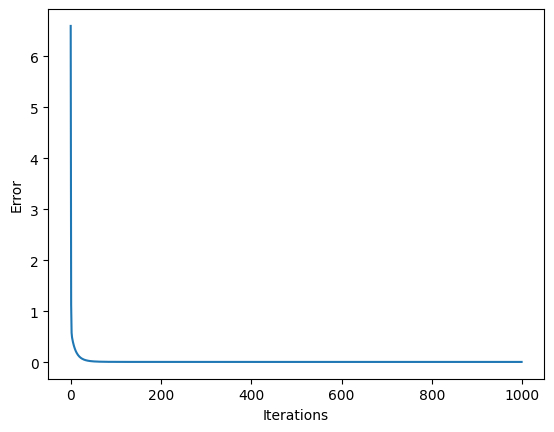

In [57]:
plt.plot(range(len(errs_decay)), errs_decay)
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.show()

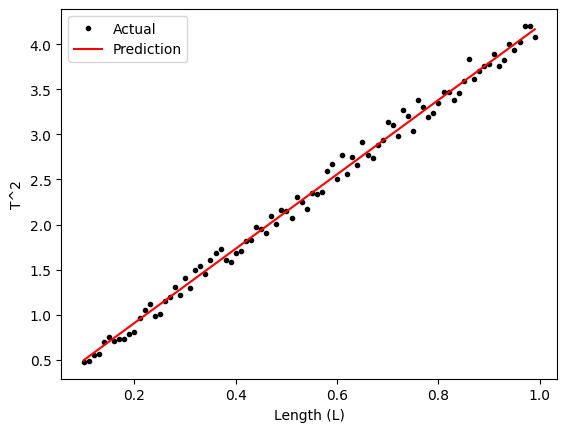

In [58]:
 # YOUR CODE HERE: Calculate the line equation where m_decay is slope, l is x value and c_decay is constant

# YOUR CODE HERE: Plot l vs tsq
# YOUR CODE HERE: Plot l vs y
y = m_decay * l + c_decay
plt.plot(l, tsq, '.k', label = 'Actual')
plt.plot(l, y, "r", label = 'Prediction')
plt.xlabel("Length (L)")
plt.ylabel("T^2")
plt.legend()
plt.show()

Thus, this is correct.

### Please answer the questions below to complete the experiment:




In [59]:
#@title State True or False: Gradient descent always finds the global minima in a single iteration? { run: "auto", form-width: "500px", display-mode: "form" }
Answer = "False" #@param ["","True","False"]


In [60]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "Good and Challenging for me" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]


In [61]:
#@title If it was too easy, what more would you have liked to be added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "lets keep it it good for practise" #@param {type:"string"}


In [62]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "Yes" #@param ["","Yes", "No"]


In [63]:
#@title  Experiment walkthrough video? { run: "auto", vertical-output: true, display-mode: "form" }
Walkthrough = "Very Useful" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [64]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "Very Useful" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [65]:
#@title Mentor Support: { run: "auto", vertical-output: true, display-mode: "form" }
Mentor_support = "Very Useful" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [66]:
#@title Run this cell to submit your notebook for grading { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id = return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")

Your submission is successful.
Ref Id: 3289
Date of submission:  14 Jun 2026
Time of submission:  17:42:50
View your submissions: https://learn-iiith.talentsprint.com/notebook_submissions
